<a href="https://colab.research.google.com/github/ymasada/my-scripts/blob/main/DMD_phase_dmd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!tar zxvf typeII.tar.gz

._II
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
II/
II/._sn2019odf
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
II/sn2019odf/
II/._.DS_Store
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
II/.DS_Store
II/._sn2019ovr
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
II/sn2019ovr/
II/._sn2019ltz
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
II/sn2019ltz/
II/._sn2019oyt
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
II/sn2019oyt/
II/._sn2019pnl
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
II/sn2019pnl/
II/sn2019pnl/._ZTF19abwsagv_20260604
tar: Ignoring unknown extended header

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
csv_path = "./II/sn2019odf/ZTF19abqrhvy_20260604/detections.csv"

In [23]:
# ZTF: fid=1 -> g band, fid=2 -> r band
selected_fid = 2   # 1: g-band, 2: r-band
band_name = {1: "g", 2: "r"}
band_color = {1: "green", 2: "red"}

In [24]:
# parameters
dt = 0.5
gp_length_scale = 5.0 #GP settings
stable_filter = True  # If True, remove eigenmodes with |lambda| >= lambda_max for each phase
n_modes_to_show = 4   # How many DMD modes to show in mode-evolution panels


In [25]:
# DMD phase settings.
# Each dictionary is an independent local DMD fit.
# t_min/t_max are measured from the first detection in the selected band.
# Set t_min/t_max to None for the full available range.
phases = [
    # Example phase-local DMDs for SN II-P r-band
    dict(name="plateau", t_min=10.0, t_max=105.0, delay=30, rank=6,
         lambda_max=1.001, trend_deg=1, t_extra=15.0),
    dict(name="drop", t_min=95.0, t_max=150.0, delay=20, rank=4,
         lambda_max=1.005, trend_deg=1, t_extra=10.0),
]

In [26]:
def mag_to_flux(mag):
    return 10.0 ** (-0.4 * mag)


def flux_to_mag(flux):
    flux = np.maximum(flux, 1e-30)
    return -2.5 * np.log10(flux)


def make_hankel_1d(y, delay):
    """
    y: shape = (n_time,)
    return H: shape = (delay, n_snapshot)
    Each column is [y_k, y_{k+1}, ..., y_{k+delay-1}].
    """
    n_time = len(y)
    n_snap = n_time - delay + 1
    if n_snap < 2:
        raise RuntimeError(
            f"delay={delay} is too large for n_time={n_time}. "
            "Use a smaller delay or a wider phase window."
        )

    H = np.zeros((delay, n_snap))
    for k in range(n_snap):
        H[:, k] = y[k:k + delay]
    return H


def dmd(X, Y, r):
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    r_eff = min(r, len(S))
    U_r = U[:, :r_eff]
    S_r = np.diag(S[:r_eff])
    V_r = Vh.conj().T[:, :r_eff]

    A_tilde = U_r.conj().T @ Y @ V_r @ np.linalg.inv(S_r)

    eigvals, W = np.linalg.eig(A_tilde)
    Phi = Y @ V_r @ np.linalg.inv(S_r) @ W

    return eigvals, Phi, S

In [27]:
def run_phase_dmd(
    phase, t_grid_all, y_gp_all, scale_logf, dt, stable_filter=True
):
    """Run local Hankel-DMD for one phase window."""
    name = phase.get("name", "phase")
    t_min = phase.get("t_min", None)
    t_max = phase.get("t_max", None)
    delay = int(phase.get("delay", 20))
    rank = int(phase.get("rank", 6))
    lambda_max = float(phase.get("lambda_max", 1.0))
    trend_deg = int(phase.get("trend_deg", 1))
    t_extra = float(phase.get("t_extra", 0.0))

    mask = np.ones_like(t_grid_all, dtype=bool)
    if t_min is not None:
        mask &= t_grid_all >= t_min
    if t_max is not None:
        mask &= t_grid_all <= t_max

    t_grid = t_grid_all[mask]
    y_grid = y_gp_all[mask]

    if len(t_grid) < delay + 2:
        raise RuntimeError(
            f"Phase '{name}' has too few grid points ({len(t_grid)}) "
            f"for delay={delay}."
        )

    # Trend subtraction. trend_deg=0 corresponds to mean subtraction.
    p = np.polyfit(t_grid, y_grid, deg=trend_deg)
    trend = np.polyval(p, t_grid)
    y_dmd_input = y_grid - trend

    H = make_hankel_1d(y_dmd_input, delay)
    X = H[:, :-1]
    Y = H[:, 1:]

    eigvals, Phi, singular_values = dmd(X, Y, rank)

    if stable_filter:
        keep = np.abs(eigvals) < lambda_max
        eigvals = eigvals[keep]
        Phi = Phi[:, keep]

    if len(eigvals) == 0:
        raise RuntimeError(
            f"Phase '{name}': no DMD modes remain after filtering. "
            "Relax lambda_max or disable stable_filter."
        )

    x0 = H[:, 0]
    b = np.linalg.lstsq(Phi, x0, rcond=None)[0]

    # DMD time begins at the start of this phase window.
    t_ext = np.arange(t_grid.min(), t_grid.max() + t_extra, dt)
    n_steps = len(t_ext)

    H_dmd = np.zeros((Phi.shape[0], n_steps), dtype=complex)
    for k in range(n_steps):
        H_dmd[:, k] = Phi @ (b * eigvals**k)

    y_dmd_norm = H_dmd[0, :].real
    trend_ext = np.polyval(p, t_ext)
    y_logf = y_dmd_norm + trend_ext + scale_logf
    y_mag = flux_to_mag(10.0 ** y_logf)

    # Mode-by-mode time evolution in the detrended log-flux space.
    n_modes = len(eigvals)
    mode_series = np.zeros((n_modes, n_steps), dtype=float)
    for j in range(n_modes):
        for k in range(n_steps):
            mode_series[j, k] = np.real(Phi[0, j] * b[j] * eigvals[j]**k)

    mode_amp = np.max(np.abs(mode_series), axis=1)
    mode_order = np.argsort(mode_amp)[::-1]

    return dict(
        name=name,
        t_grid=t_grid,
        t_ext=t_ext,
        y_mag=y_mag,
        trend_poly=p,
        y_dmd_input=y_dmd_input,
        eigvals=eigvals,
        Phi=Phi,
        b=b,
        singular_values=singular_values,
        mode_series=mode_series,
        mode_order=mode_order,
        delay=delay,
        rank=rank,
        lambda_max=lambda_max,
        trend_deg=trend_deg,
        t_min=t_min,
        t_max=t_max,
    )

In [28]:
# ============================================================
# 1. Load data
# ============================================================

det = pd.read_csv(csv_path)

# corrected magnitude if available; otherwise raw mag
det["mag_use"] = det["mag_corr"].fillna(det["mag"])
det["emag_use"] = det["e_mag_corr"].fillna(det["e_mag"])

det = det[np.isfinite(det["mag_use"])]
det = det[det["fid"] == selected_fid].copy()
det = det.sort_values("mjd")

if len(det) < 5:
    raise RuntimeError("Too few data points for the selected band.")

# relative time
t0 = det["mjd"].min()
det["t"] = det["mjd"] - t0

In [29]:
# ============================================================
# 2. magnitude -> log-flux
# ============================================================

det["flux"] = mag_to_flux(det["mag_use"])
det["log_flux"] = np.log10(det["flux"])

# band-wise centering in log-flux space
scale_logf = np.mean(det["log_flux"])
det["log_flux_norm"] = det["log_flux"] - scale_logf


# ============================================================
# 3. GP interpolation onto a uniform grid
# ============================================================

t_grid_all = np.arange(det["t"].min(), det["t"].max(), dt)

t_obs = det["t"].values[:, None]
y_obs = det["log_flux_norm"].values

kernel = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * RBF(length_scale=gp_length_scale, length_scale_bounds=(0.5, 30.0))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-4,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=0,
)

gp.fit(t_obs, y_obs)
y_gp_all, y_gp_std_all = gp.predict(t_grid_all[:, None], return_std=True)

# GP curve in magnitude for reference.
y_gp_logf_all = y_gp_all + scale_logf
y_gp_mag_all = flux_to_mag(10.0 ** y_gp_logf_all)

In [30]:
# ============================================================
# 4. Phase-local DMDs
# ============================================================

results = []
for ph in phases:
    results.append(run_phase_dmd(ph, t_grid_all, y_gp_all, scale_logf, dt, stable_filter))

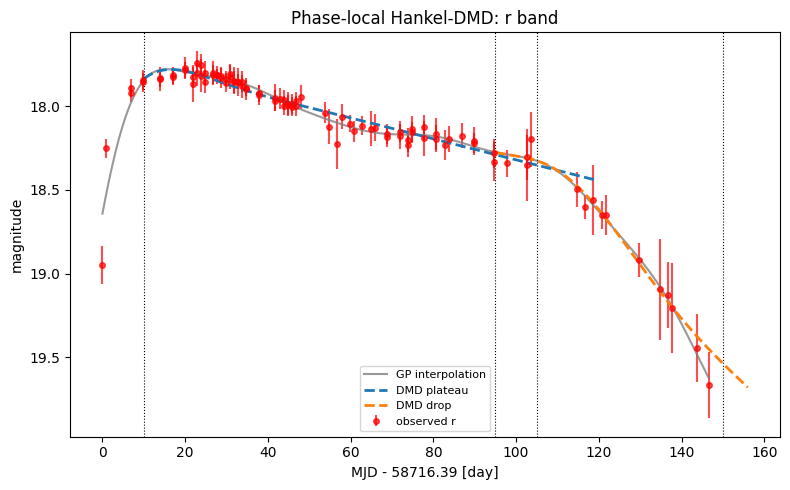

In [31]:
# ============================================================
# 5. Plot: all phase-local DMD curves together
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    det["t"], det["mag_use"], yerr=det["emag_use"],
    fmt="o", ms=4, alpha=0.7,
    color=band_color[selected_fid],
    label=f"observed {band_name[selected_fid]}",
)

ax.plot(
    t_grid_all, y_gp_mag_all,
    color="gray", lw=1.5, alpha=0.8,
    label="GP interpolation",
)

# Plot each phase DMD solution.
for res in results:
    ax.plot(
        res["t_ext"], res["y_mag"], "--", lw=2,
        label=f"DMD {res['name']}"
    )
    if res["t_min"] is not None:
        ax.axvline(res["t_min"], color="k", ls=":", lw=0.8)
    if res["t_max"] is not None:
        ax.axvline(res["t_max"], color="k", ls=":", lw=0.8)

ax.invert_yaxis()
ax.set_xlabel(f"MJD - {t0:.2f} [day]")
ax.set_ylabel("magnitude")
ax.legend(fontsize=8)
ax.set_title(f"Phase-local Hankel-DMD: {band_name[selected_fid]} band")
plt.tight_layout()
plt.show()

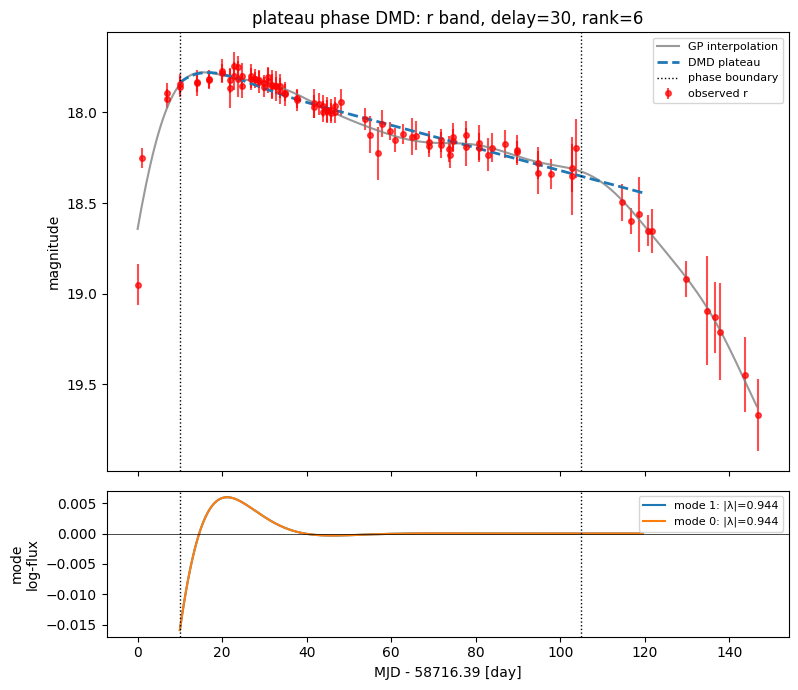

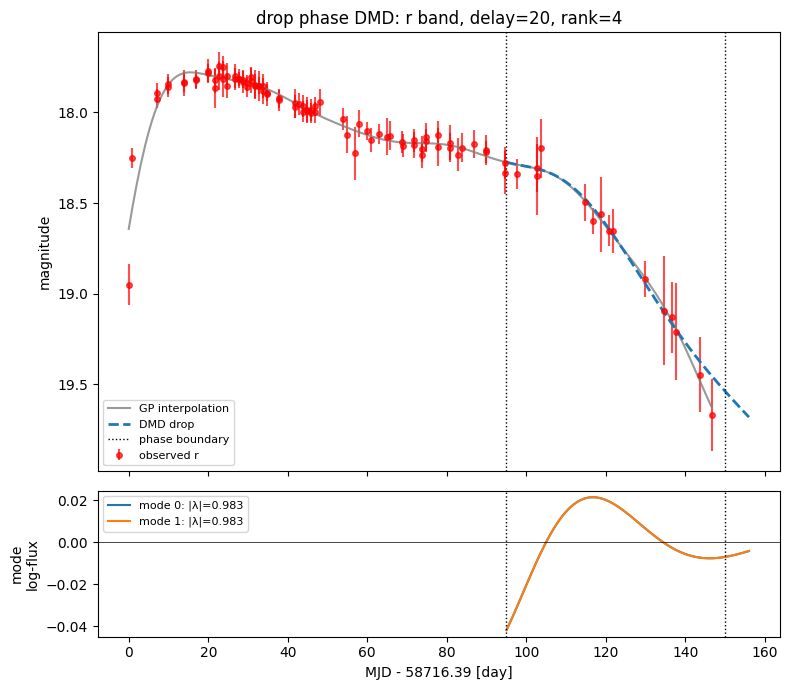

In [32]:
# ============================================================
# 6. Plot mode evolution for each phase
# ============================================================

for res in results:
    n_modes = len(res["eigvals"])
    n_show = min(n_modes_to_show, n_modes)

    fig, (ax, axm) = plt.subplots(
        2, 1, figsize=(8, 7), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    ax.errorbar(
        det["t"], det["mag_use"], yerr=det["emag_use"],
        fmt="o", ms=4, alpha=0.7,
        color=band_color[selected_fid],
        label=f"observed {band_name[selected_fid]}",
    )
    ax.plot(t_grid_all, y_gp_mag_all, color="gray", lw=1.5, alpha=0.8,
            label="GP interpolation")
    ax.plot(res["t_ext"], res["y_mag"], "--", lw=2,
            label=f"DMD {res['name']}")

    if res["t_min"] is not None:
        ax.axvline(res["t_min"], color="k", ls=":", lw=1)
    if res["t_max"] is not None:
        ax.axvline(res["t_max"], color="k", ls=":", lw=1, label="phase boundary")

    ax.invert_yaxis()
    ax.set_ylabel("magnitude")
    ax.legend(fontsize=8)
    ax.set_title(
        f"{res['name']} phase DMD: {band_name[selected_fid]} band, "
        f"delay={res['delay']}, rank={res['rank']}"
    )

    for jj in range(n_show):
        j = res["mode_order"][jj]
        axm.plot(
            res["t_ext"], res["mode_series"][j], lw=1.5,
            label=f"mode {j}: |λ|={abs(res['eigvals'][j]):.3f}"
        )

    axm.axhline(0.0, color="k", lw=0.5)
    if res["t_min"] is not None:
        axm.axvline(res["t_min"], color="k", ls=":", lw=1)
    if res["t_max"] is not None:
        axm.axvline(res["t_max"], color="k", ls=":", lw=1)

    axm.set_xlabel(f"MJD - {t0:.2f} [day]")
    axm.set_ylabel("mode\nlog-flux")
    axm.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [33]:
# ============================================================
# 7. Diagnostics
# ============================================================

print(f"Selected band: {band_name[selected_fid]} (fid={selected_fid})")
print(f"Number of observed points: {len(det)}")

for res in results:
    print("\n" + "=" * 60)
    print(f"Phase: {res['name']}")
    print(f"DMD time range: {res['t_grid'].min():.2f} -- {res['t_grid'].max():.2f} days")
    print(
        f"delay={res['delay']}, requested rank={res['rank']}, "
        f"retained modes={len(res['eigvals'])}, "
        f"lambda_max={res['lambda_max']}, trend_deg={res['trend_deg']}"
    )

    print("Leading singular values:")
    for j, s in enumerate(res["singular_values"][:10]):
        print(f"  s[{j}] = {s:.4e}")

    print("DMD modes:")
    for j, lam in enumerate(res["eigvals"]):
        growth = np.log(np.abs(lam)) / dt
        freq = np.angle(lam) / (2 * np.pi * dt)
        timescale = np.inf if growth == 0 else -1.0 / growth
        print(
            f"mode {j:2d}: "
            f"lambda={lam:.5f}, "
            f"|lambda|={abs(lam):.5f}, "
            f"growth={growth:.4e} 1/day, "
            f"tau_decay={timescale:.3f} day, "
            f"freq={freq:.4e} cycle/day"
        )

Selected band: r (fid=2)
Number of observed points: 95

Phase: plateau
DMD time range: 10.00 -- 105.00 days
delay=30, requested rank=6, retained modes=2, lambda_max=1.001, trend_deg=1
Leading singular values:
  s[0] = 8.2536e-01
  s[1] = 3.6862e-01
  s[2] = 8.0962e-02
  s[3] = 3.2121e-02
  s[4] = 5.3502e-03
  s[5] = 5.8427e-04
  s[6] = 5.7631e-05
  s[7] = 3.5652e-06
  s[8] = 1.2853e-07
  s[9] = 3.3066e-09
DMD modes:
mode  0: lambda=0.94226+0.05941j, |lambda|=0.94413, growth=-1.1498e-01 1/day, tau_decay=8.697 day, freq=2.0045e-02 cycle/day
mode  1: lambda=0.94226-0.05941j, |lambda|=0.94413, growth=-1.1498e-01 1/day, tau_decay=8.697 day, freq=-2.0045e-02 cycle/day

Phase: drop
DMD time range: 95.00 -- 146.50 days
delay=20, requested rank=4, retained modes=2, lambda_max=1.005, trend_deg=1
Leading singular values:
  s[0] = 1.0877e+00
  s[1] = 5.5516e-01
  s[2] = 6.7941e-02
  s[3] = 7.2894e-03
  s[4] = 4.5162e-04
  s[5] = 6.6966e-06
  s[6] = 8.0254e-08
  s[7] = 2.4285e-09
  s[8] = 5.2686e-1